In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

n_estampas = 100
estampas_por_sobre = 7

np.random.seed(2026)

#fijar una secuencia de sobres para cada simulación
M_values = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
resultados = [] 

In [2]:
# para cada valor de M, realizar R = 10000 simulaciones y registrar si al cabo de esos albunes se ha llenado el álbum (+1) o no (0
R = 10000
for M in M_values:
    exitos = 0
    for _ in range(R): 
        album = np.zeros(n_estampas, dtype=bool)  
        sobres = np.array([
            np.random.choice(n_estampas, size=estampas_por_sobre, replace=False)
            for _ in range(M)
        ])
        album[sobres] = True  
        if np.all(album):  
            exitos += 1
    proporcion = exitos / R
    resultados.append(proporcion)  
    print(f"M = {M}: {exitos} de {R} álbumes llenos, proporción = {proporcion}")

M = 20: 0 de 10000 álbumes llenos, proporción = 0.0
M = 25: 0 de 10000 álbumes llenos, proporción = 0.0
M = 30: 0 de 10000 álbumes llenos, proporción = 0.0
M = 35: 0 de 10000 álbumes llenos, proporción = 0.0
M = 40: 19 de 10000 álbumes llenos, proporción = 0.0019
M = 45: 143 de 10000 álbumes llenos, proporción = 0.0143
M = 50: 571 de 10000 álbumes llenos, proporción = 0.0571
M = 55: 1494 de 10000 álbumes llenos, proporción = 0.1494
M = 60: 2690 de 10000 álbumes llenos, proporción = 0.269
M = 65: 3963 de 10000 álbumes llenos, proporción = 0.3963
M = 70: 5250 de 10000 álbumes llenos, proporción = 0.525
M = 75: 6432 de 10000 álbumes llenos, proporción = 0.6432
M = 80: 7398 de 10000 álbumes llenos, proporción = 0.7398


In [ ]:
#calcular la proporcion de álbumes llenos para cada valor de M y graficar los resultados en una grafica de puntos
min_sobres_posibles = ceil(n_estampas / estampas_por_sobre)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    M_values,
    resultados,
    marker='o',
    markersize=7,
    linewidth=2.5,
    color='#2563eb',
    label='Proporción simulada'
)
ax.fill_between(M_values, resultados, color='#2563eb', alpha=0.12)

for M, proporcion in zip(M_values, resultados):
    ax.annotate(
        f'{proporcion:.2f}',
        (M, proporcion),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

ax.axvline(min_sobres_posibles, color='#f97316', linestyle='--', linewidth=2, label='Mínimo teórico')
ax.set_title('Probabilidad de llenar el álbum según el número de sobres', fontsize=14, weight='bold')
ax.set_xlabel('Número de sobres (M)', fontsize=11)
ax.set_ylabel('Proporción de álbumes llenos', fontsize=11)
ax.set_xticks(M_values)
ax.set_ylim(-0.03, 1.03)
ax.set_xlim(min(M_values) - 3, max(M_values) + 3)
ax.grid(True, linestyle='--', alpha=0.45)
ax.legend(loc='upper left')

fig.tight_layout()
fig.savefig('grafica_linea_probabilidad.png', dpi=200)
plt.show()

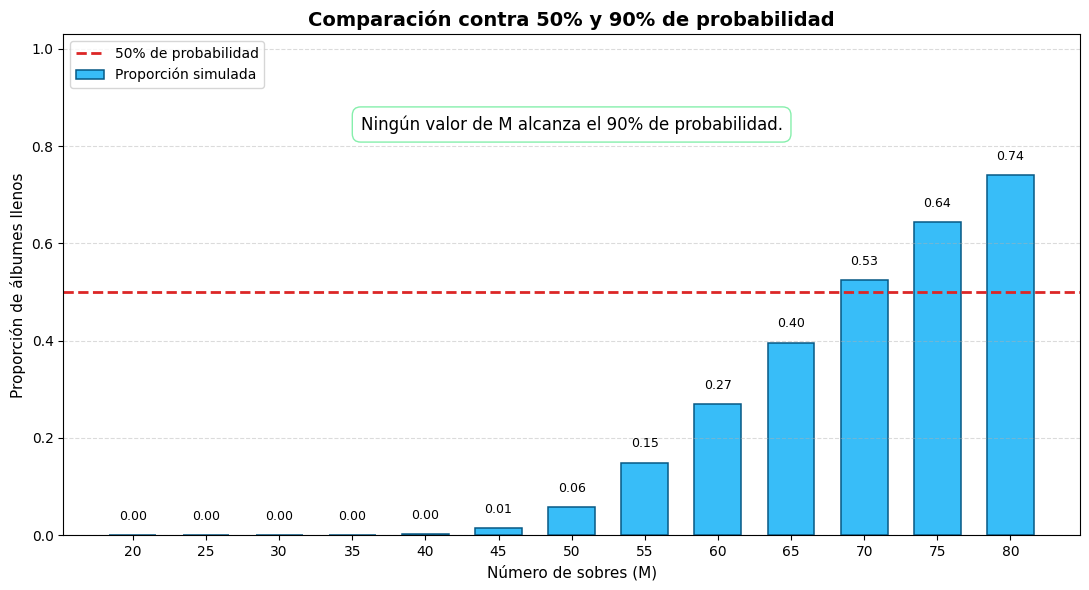

In [4]:
#Visualizacion
#elabora una grafica de barras con M en el eje horizontal y la probabilidad estimada en el eje vertical.
#Añadir una linea horizontal en 0.5 para identificar si algun valor de M alcanza al menos 50%.
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    M_values,
    resultados,
    width=3.2,
    color='#38bdf8',
    edgecolor='#075985',
    linewidth=1.1,
    label='Proporción simulada'
)
ax.axhline(0.5, color='#dc2626', linestyle='--', linewidth=2, label='50% de probabilidad')

for bar, proporcion in zip(bars, resultados):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f'{proporcion:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title('Comparación contra 50% y 90% de probabilidad', fontsize=14, weight='bold')
ax.set_xlabel('Número de sobres (M)', fontsize=11)
ax.set_ylabel('Proporción de álbumes llenos', fontsize=11)
ax.set_xticks(M_values)
ax.set_ylim(0, 1.03)
ax.grid(axis='y', linestyle='--', alpha=0.45)
ax.legend(loc='upper left')

if max(resultados) < 0.9:
    ax.text(
        0.5,
        0.82,
        'Ningún valor de M alcanza el 90% de probabilidad.',
        transform=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#86efac')
    )

fig.tight_layout()
fig.savefig('grafica_barras_probabilidad.png', dpi=200)
plt.show()  

In [5]:
#1. para que valor de M la proabilidad estimada supera por primera vez eñ 50%? Y el 90%?
M_50 = None
M_90 = None
for M, proporcion in zip(M_values, resultados):
    if M_50 is None and proporcion >= 0.5:
        M_50 = M
    if M_90 is None and proporcion >= 0.9:
        M_90 = M
    if M_50 is not None and M_90 is not None:
        break
print(f"El número de sobres necesario para tener al menos un 50% de probabilidad de llenar el álbum es: {M_50}")
if M_90 is None:
    print("Con los valores de M probados, no se alcanza el 90% de probabilidad.")
else:
    print(f"El número de sobres necesario para tener al menos un 90% de probabilidad de llenar el álbum es: {M_90}")


El número de sobres necesario para tener al menos un 50% de probabilidad de llenar el álbum es: 70
Con los valores de M probados, no se alcanza el 90% de probabilidad.


In [ ]:
#2. Compara el valor de M que da una proabilidad del 50% con la mediana del número de sobres necesarios que calculo en el apartado anterior. ¿Son similares? ¿Por qué?
print(
    "El valor de M que supera el 50% debe ser parecido a la mediana del número de sobres necesarios, "
    "porque la mediana es justamente el punto donde aproximadamente la mitad de las simulaciones ya llenaron el álbum. "
    f"En esta simulación, el primer M con probabilidad mayor o igual a 50% es {M_50}.")

El valor de M que supera el 50% debe ser parecido a la mediana del número de sobres necesarios, porque la mediana es justamente el punto donde aproximadamente la mitad de las simulaciones ya llenaron el álbum. En esta simulación, el primer M con probabilidad mayor o igual a 50% es 70.


In [8]:
#3. Basandonos en la teoria del coleccionista, la proabilidad de no haber obtenido una estampa especifica despues de M sobres es aproximadamente exp(-M * estampas_por_sobre / n_estampas). utilizando la union de eventos, obtener una cota superior para la proabilidad de que falte al menos un cromo. Aplicar esta cota para M = 50 sobres y comparar con la proabilidad de exito estimada en su simulacion. ¿La cota es util?
M = 50
prob_falta_una_estampa = np.exp(-M * estampas_por_sobre / n_estampas)
cota_superior_falta_alguna = n_estampas * prob_falta_una_estampa
cota_superior_falta_alguna = min(1, cota_superior_falta_alguna)
proporcion_simulacion = resultados[M_values.index(M)]
print(f"Cota superior para la probabilidad de que falte al menos una estampa con M = {M}: {cota_superior_falta_alguna}")
print(f"Proporción de éxito estimada en simulación para M = {M}: {proporcion_simulacion}")
print(
    "La cota no es muy útil para M = 50, porque da un valor cercano a 1 para la probabilidad de que falte alguna estampa. "
    "Eso solo confirma que puede faltar alguna, pero no aproxima bien la probabilidad de éxito."
)


Cota superior para la probabilidad de que falte al menos una estampa con M = 50: 1
Proporción de éxito estimada en simulación para M = 50: 0.0571
La cota no es muy útil para M = 50, porque da un valor cercano a 1 para la probabilidad de que falte alguna estampa. Eso solo confirma que puede faltar alguna, pero no aproxima bien la probabilidad de éxito.
